# Импорты

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests

import backtrader as bt
from dateutil.relativedelta import relativedelta

# Датафид

In [4]:
class PandasOHLCV(bt.feeds.PandasData):
    """
    Требуемые колонки в DataFrame:
    open, high, low, close, volume
    Индекс: datetime
    """
    params = (
        ("datetime", None),
        ("open", "open"),
        ("high", "high"),
        ("low", "low"),
        ("close", "close"),
        ("volume", "volume"),
        ("openinterest", -1),
    )

# Кастомные индикаторы

In [5]:
class VolumeRatio(bt.Indicator):
    lines = ("ratio",)
    params = (("period", 20),)

    def __init__(self):
        vol_ma = bt.indicators.SimpleMovingAverage(self.data.volume, period=self.p.period)
        self.lines.ratio = self.data.volume / vol_ma


class PullbackPct(bt.Indicator):
    lines = ("pullback_pct",)
    params = (("lookback", 10),)

    def __init__(self):
        hh = bt.indicators.Highest(self.data.high(-1), period=self.p.lookback)
        self.lines.pullback_pct = (hh - self.data.close) / hh


class EMASlope(bt.Indicator):
    lines = ("slope",)
    params = (("period", 10),)

    def __init__(self):
        self.lines.slope = self.data - self.data(-self.p.period)

# Analyzer для списка сделок

In [6]:
class TradeListAnalyzer(bt.Analyzer):
    def start(self):
        self.trades = []

    def notify_trade(self, trade):
        if not trade.isclosed:
            return

        dt_open = bt.num2date(trade.dtopen)
        dt_close = bt.num2date(trade.dtclose)

        price_out = trade.price + (trade.pnl / trade.size if trade.size else 0.0)

        self.trades.append({
            "entry_time": pd.Timestamp(dt_open),
            "exit_time": pd.Timestamp(dt_close),
            "size": trade.size,
            "price_in": trade.price,
            "price_out": price_out,
            "pnl_gross": trade.pnl,
            "pnl_net": trade.pnlcomm,
            "barlen": trade.barlen,
        })

    def get_analysis(self):
        return self.trades

# Стратегия BTC trend

In [39]:
class BTCTrendPullbackStrategy(bt.Strategy):
    params = dict(
        ema_fast=20,
        ema_slow=100,
        atr_period=14,
        swing_window=10,

        pullback_min_pct=0.0005,
        pullback_max_pct=0.05,
        max_close_above_fast_ema_pct=0.03,
        min_atr_pct=0.0005,
        max_atr_pct=0.15,
        use_breakout_trigger=False,

        risk_per_trade=0.01,
        rr_target=1.5,
        atr_stop_mult=1.5,
        max_bars_in_trade=72,

        debug=False,
    )

    def log(self, txt):
        if self.p.debug:
            dt = self.datas[0].datetime.datetime(0)
            print(f"{dt} | {txt}")

    def __init__(self):
        data = self.datas[0]

        self.order = None
        self.entry_bar = None
        self.entry_price = None
        self.stop_price = None
        self.take_price = None

        self.ema_fast = bt.indicators.EMA(data.close, period=self.p.ema_fast)
        self.ema_slow = bt.indicators.EMA(data.close, period=self.p.ema_slow)

        self.atr = bt.indicators.ATR(data, period=self.p.atr_period)
        self.atr_pct = self.atr / data.close

        self.pullback_pct = PullbackPct(data, lookback=self.p.swing_window)
        self.recent_low = bt.indicators.Lowest(data.low(-1), period=self.p.swing_window)

        micro_window = max(3, self.p.swing_window // 2)
        self.micro_high = bt.indicators.Highest(data.high(-1), period=micro_window)

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:
            if order.isbuy():
                self.log(f"BUY EXECUTED | price={order.executed.price:.2f}, size={order.executed.size:.6f}")
            elif order.issell():
                self.log(f"SELL EXECUTED | price={order.executed.price:.2f}, size={order.executed.size:.6f}")

        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log(f"ORDER FAILED | status={order.getstatusname()}")

        self.order = None

    def notify_trade(self, trade):
        if trade.isclosed:
            self.log(f"TRADE CLOSED | gross={trade.pnl:.2f}, net={trade.pnlcomm:.2f}")

    def _long_signal(self):
        close = self.data.close[0]

        trend_up = close > self.ema_slow[0]

        pullback_ok = (
            np.isfinite(self.pullback_pct[0]) and
            (self.pullback_pct[0] >= self.p.pullback_min_pct) and
            (self.pullback_pct[0] <= self.p.pullback_max_pct) and
            (close >= self.ema_fast[0] * (1 - self.p.max_close_above_fast_ema_pct))
        )

        volatility_ok = (
            np.isfinite(self.atr_pct[0]) and
            (self.atr_pct[0] >= self.p.min_atr_pct) and
            (self.atr_pct[0] <= self.p.max_atr_pct)
        )

        if self.p.use_breakout_trigger:
            trigger_long = close > self.micro_high[0]
        else:
            trigger_long = (
                (close > self.ema_fast[0]) and
                (self.data.close[-1] <= self.ema_fast[-1])
            )

        return trend_up and pullback_ok and volatility_ok and trigger_long

    def _calc_position_size(self, entry_price, stop_price):
        cash = self.broker.getcash()
        risk_amount = cash * self.p.risk_per_trade
        stop_distance = entry_price - stop_price

        if stop_distance <= 0:
            return 0.0

        size = risk_amount / stop_distance
        max_affordable = cash / entry_price if entry_price > 0 else 0.0
        size = min(size, max_affordable)

        if not np.isfinite(size) or size <= 0:
            return 0.0

        return size

    def next(self):
        if self.order:
            return

        close = self.data.close[0]

        if self.position:
            bars_held = len(self) - self.entry_bar if self.entry_bar is not None else 0

            if self.data.low[0] <= self.stop_price:
                self.log(f"EXIT STOP | stop={self.stop_price:.2f}")
                self.order = self.close()
                return

            if self.data.high[0] >= self.take_price:
                self.log(f"EXIT TAKE | take={self.take_price:.2f}")
                self.order = self.close()
                return

            if bars_held >= self.p.max_bars_in_trade:
                self.log("EXIT TIMEOUT")
                self.order = self.close()
                return

        if not self.position and self._long_signal():
            entry_price = close
            atr_stop = entry_price - self.p.atr_stop_mult * self.atr[0]
            structural_stop = self.recent_low[0]
            stop_price = min(structural_stop, atr_stop)

            if not np.isfinite(stop_price) or stop_price >= entry_price:
                return

            size = self._calc_position_size(entry_price, stop_price)
            if size <= 0:
                return

            take_price = entry_price + self.p.rr_target * (entry_price - stop_price)

            self.entry_price = entry_price
            self.stop_price = stop_price
            self.take_price = take_price
            self.entry_bar = len(self)

            self.log(
                f"ENTRY LONG | entry={entry_price:.2f}, stop={stop_price:.2f}, "
                f"take={take_price:.2f}, size={size:.6f}"
            )
            self.order = self.buy(size=size)

# Функция одиночного прогона бэктеста

In [22]:
def run_backtest_bt(
    df: pd.DataFrame,
    strategy_cls=BTCTrendPullbackStrategy,
    strategy_params=None,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
):
    if strategy_params is None:
        strategy_params = {}

    data = df.copy()
    required_cols = {"open", "high", "low", "close", "volume"}
    missing = required_cols - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be DatetimeIndex")

    data = data.sort_index()

    cerebro = bt.Cerebro(stdstats=False)
    cerebro.broker.setcash(initial_cash)
    cerebro.broker.setcommission(commission=commission)
    cerebro.broker.set_slippage_perc(perc=slippage_perc)

    feed = PandasOHLCV(dataname=data)
    cerebro.adddata(feed)

    cerebro.addstrategy(strategy_cls, **strategy_params)

    cerebro.addanalyzer(bt.analyzers.TimeReturn, _name="timereturn")
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="tradeanalyzer")
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name="sharpe", timeframe=bt.TimeFrame.Days, annualize=True)
    cerebro.addanalyzer(TradeListAnalyzer, _name="tradelist")

    results = cerebro.run()
    strat = results[0]

    final_value = cerebro.broker.getvalue()
    pnl = final_value - initial_cash

    # -------- helper ----------
    def safe_float(x, default=0.0):
        if x is None:
            return float(default)
        try:
            x = float(x)
        except (TypeError, ValueError):
            return float(default)
        if not np.isfinite(x):
            return float(default)
        return x

    # Equity curve
    rets = strat.analyzers.timereturn.get_analysis()
    returns_series = pd.Series(rets, dtype=float)
    if len(returns_series) > 0:
        equity_curve = (1 + returns_series).cumprod() * initial_cash
        equity_df = pd.DataFrame({"equity": equity_curve})
        equity_df.index = pd.to_datetime(equity_df.index)
    else:
        equity_df = pd.DataFrame(columns=["equity"])

    # Trades
    trades = strat.analyzers.tradelist.get_analysis()
    trades_df = pd.DataFrame(trades) if trades else pd.DataFrame()

    trade_an = strat.analyzers.tradeanalyzer.get_analysis()
    dd_an = strat.analyzers.drawdown.get_analysis()
    sharpe_an = strat.analyzers.sharpe.get_analysis()

    total_trades = trade_an.get("total", {}).get("closed", 0) if isinstance(trade_an, dict) else 0
    won_total = trade_an.get("won", {}).get("total", 0) if isinstance(trade_an, dict) else 0

    gross_profit = trade_an.get("won", {}).get("pnl", {}).get("total", 0.0) if isinstance(trade_an, dict) else 0.0
    gross_loss_abs = abs(trade_an.get("lost", {}).get("pnl", {}).get("total", 0.0)) if isinstance(trade_an, dict) else 0.0
    profit_factor = gross_profit / gross_loss_abs if gross_loss_abs > 0 else np.nan

    sharpe_value = sharpe_an.get("sharperatio", 0.0) if isinstance(sharpe_an, dict) else 0.0
    max_dd_value = dd_an.get("max", {}).get("drawdown", 0.0) if isinstance(dd_an, dict) else 0.0

    metrics = {
        "initial_cash": safe_float(initial_cash),
        "final_value": safe_float(final_value),
        "net_profit": safe_float(pnl),
        "total_return_pct": safe_float((final_value / initial_cash - 1) * 100),
        "max_drawdown_pct": safe_float(max_dd_value),
        "n_trades": int(total_trades),
        "win_rate_pct": safe_float((won_total / total_trades) * 100 if total_trades > 0 else 0.0),
        "profit_factor": safe_float(profit_factor, default=0.0),
        "sharpe": safe_float(sharpe_value, default=0.0),
    }

    if plot:
        cerebro.plot(style="candlestick")

    return {
        "metrics": metrics,
        "trades_df": trades_df,
        "equity_df": equity_df,
        "strategy": strat,
        "cerebro": cerebro,
    }

# Дефолтные параметры стратегии

In [40]:
DEFAULT_PARAMS = dict(
    ema_fast=20,
    ema_slow=100,
    atr_period=14,
    swing_window=10,

    pullback_min_pct=0.0005,
    pullback_max_pct=0.05,
    max_close_above_fast_ema_pct=0.03,
    min_atr_pct=0.0005,
    max_atr_pct=0.15,
    use_breakout_trigger=False,

    risk_per_trade=0.01,
    rr_target=1.5,
    atr_stop_mult=1.5,
    max_bars_in_trade=72,
    debug=False,
)

# Загрузка и подготовка данных

In [27]:
def load_binance_klines(
    symbol: str = "BTCUSDT",
    interval: str = "5m",
    limit_total: int = 10_000,
    drop_timezone: bool = True,
) -> pd.DataFrame:
    """
    Загружает историю свечей Binance пачками по 1000, двигаясь назад во времени.

    Возвращает DataFrame:
    - index: datetime
    - columns: open, high, low, close, volume

    Parameters
    ----------
    symbol : str
        Торговый символ Binance, например BTCUSDT.
    interval : str
        Интервал свечей, например 5m, 15m, 1h.
    limit_total : int
        Сколько свечей максимум загрузить.
    drop_timezone : bool
        Если True, убирает timezone из индекса.
        Для Backtrader обычно так удобнее.
    """
    url = "https://api.binance.com/api/v3/klines"
    per_request = 1000
    all_klines = []
    end_time = None

    with requests.Session() as session:
        session.trust_env = False

        while len(all_klines) < limit_total:
            params = {
                "symbol": symbol,
                "interval": interval,
                "limit": per_request,
            }

            if end_time is not None:
                params["endTime"] = end_time - 1

            resp = session.get(url, params=params, timeout=20)
            resp.raise_for_status()
            klines = resp.json()

            if not klines:
                break

            all_klines = klines + all_klines
            end_time = klines[0][0]

            if len(klines) < per_request:
                break

            time.sleep(0.1)

    if not all_klines:
        raise ValueError("Binance returned no klines.")

    all_klines = all_klines[-limit_total:]

    df = pd.DataFrame(
        all_klines,
        columns=[
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
        ]
    )

    # Числовые колонки
    numeric_cols = ["open", "high", "low", "close", "volume"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Дата
    df["datetime"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)

    # Оставляем только то, что нужно стратегии
    df = df[["datetime", "open", "high", "low", "close", "volume"]].copy()

    # Сортировка, удаление дублей, удаление пропусков
    df = df.sort_values("datetime")
    df = df.drop_duplicates(subset=["datetime"])
    df = df.dropna(subset=["open", "high", "low", "close", "volume"])

    # Индекс
    df = df.set_index("datetime")

    # Для Backtrader обычно удобнее naive datetime index
    if drop_timezone:
        df.index = df.index.tz_convert(None)

    # Финальная сортировка на всякий случай
    df = df.sort_index()

    # Базовая проверка
    if df.empty:
        raise ValueError("Prepared DataFrame is empty.")

    expected_cols = ["open", "high", "low", "close", "volume"]
    if list(df.columns) != expected_cols:
        raise ValueError(f"Unexpected columns: {df.columns.tolist()}")

    return df


# ====== Параметры загрузки ======
SYMBOL = "BTCUSDT"
INTERVAL = "5m"
LIMIT_TOTAL = 100_000


# ====== Загрузка ======
df = load_binance_klines(
    symbol=SYMBOL,
    interval=INTERVAL,
    limit_total=LIMIT_TOTAL,
    drop_timezone=True,
)


# ====== Проверка ======
print("Data loaded successfully")
print(f"Symbol: {SYMBOL}")
print(f"Interval: {INTERVAL}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"Index type: {type(df.index)}")
print(f"Timezone: {df.index.tz}")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicated index:", df.index.duplicated().sum())

display(df.head())
display(df.tail())

Data loaded successfully
Symbol: BTCUSDT
Interval: 5m
Rows: 100,000
Columns: ['open', 'high', 'low', 'close', 'volume']
Index type: <class 'pandas.DatetimeIndex'>
Timezone: None
Date range: 2025-05-02 08:10:00 -> 2026-04-14 13:25:00

Missing values:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Duplicated index: 0


,open,high,low,close,volume
datetime,,,,,
2025-05-02 08:10:00,96499.37,96579.37,96484.49,96567.54,51.80262
2025-05-02 08:15:00,96567.54,96658.00,96540.19,96657.99,64.77434
2025-05-02 08:20:00,96658.00,96665.98,96646.35,96650.95,17.13931
2025-05-02 08:25:00,96650.95,96651.05,96594.33,96626.05,19.74307
2025-05-02 08:30:00,96626.05,96626.05,96477.51,96481.42,78.81045


,open,high,low,close,volume
datetime,,,,,
2026-04-14 13:05:00,74597.78,74613.13,74537.50,74583.65,54.92491
2026-04-14 13:10:00,74583.65,74583.65,74528.38,74576.51,31.12883
2026-04-14 13:15:00,74576.52,74681.13,74555.00,74621.91,56.13021
2026-04-14 13:20:00,74621.91,74732.94,74621.90,74712.88,58.10288
2026-04-14 13:25:00,74712.89,74712.89,74703.26,74703.26,1.17239


# Быстрый одиночный прогон

In [12]:
result = run_backtest_bt(
    df=df,
    strategy_params=DEFAULT_PARAMS,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
)

print(result["metrics"])
result["trades_df"].tail()

{'initial_cash': 10000.0, 'final_value': 10116.283718469509, 'net_profit': 116.28371846950904, 'total_return_pct': 1.162837184695098, 'max_drawdown_pct': 1.122741001733133, 'n_trades': 1, 'win_rate_pct': 100.0, 'profit_factor': inf, 'sharpe': 2.3552652976419486}


,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen
0,2026-03-31 15:15:00,2026-03-31 23:35:00,0.0,67255.158342,67255.158342,122.941358,116.283718,100


# График equity curve

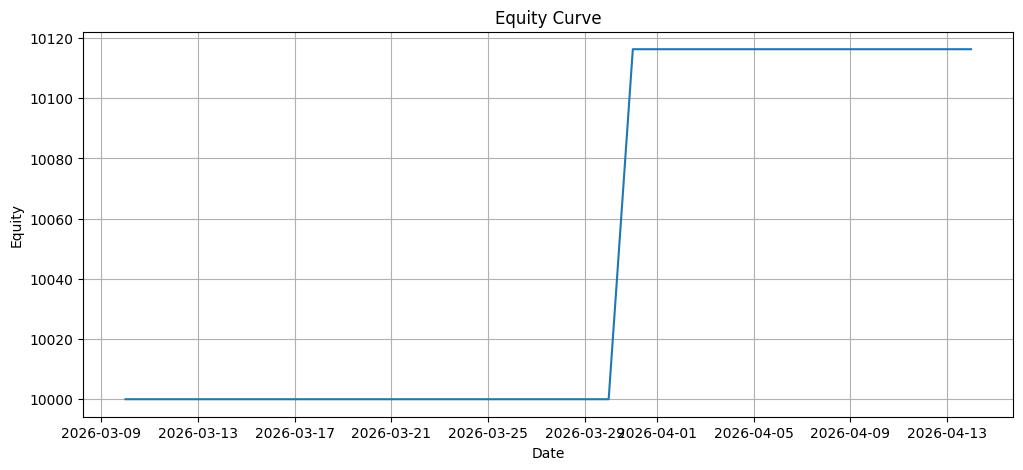

In [13]:
eq = result["equity_df"]

if not eq.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(eq.index, eq["equity"])
    plt.title("Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

# Optuna objective

In [41]:
def make_optuna_objective_bt(
    df: pd.DataFrame,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades=3,
):
    def objective(trial):
        params = dict(
            ema_fast=trial.suggest_int("ema_fast", 8, 25),
            ema_slow=trial.suggest_int("ema_slow", 50, 120),
            atr_period=trial.suggest_int("atr_period", 10, 30),
            swing_window=trial.suggest_int("swing_window", 5, 15),

            pullback_min_pct=trial.suggest_float("pullback_min_pct", 0.0005, 0.003),
            pullback_max_pct=trial.suggest_float("pullback_max_pct", 0.02, 0.05),
            max_close_above_fast_ema_pct=trial.suggest_float("max_close_above_fast_ema_pct", 0.01, 0.03),

            min_atr_pct=trial.suggest_float("min_atr_pct", 0.0005, 0.003),
            max_atr_pct=trial.suggest_float("max_atr_pct", 0.08, 0.15),

            use_breakout_trigger=trial.suggest_categorical("use_breakout_trigger", [False, True]),

            # фиксируем часть risk-параметров, чтобы уменьшить переобучение
            risk_per_trade=0.01,
            rr_target=trial.suggest_float("rr_target", 1.0, 2.0),
            atr_stop_mult=trial.suggest_float("atr_stop_mult", 1.0, 2.0),
            max_bars_in_trade=72,

            debug=False,
        )

        if params["ema_fast"] >= params["ema_slow"]:
            return -1e9
        if params["pullback_min_pct"] >= params["pullback_max_pct"]:
            return -1e9

        try:
            result = run_backtest_bt(
                df=df,
                strategy_params=params,
                initial_cash=initial_cash,
                commission=commission,
                slippage_perc=slippage_perc,
                plot=False,
            )
            metrics = result["metrics"]
        except Exception as e:
            print("Trial failed:", e)
            return -1e9

        n_trades = metrics["n_trades"]
        total_return = metrics["total_return_pct"]
        max_dd = abs(metrics["max_drawdown_pct"])
        pf = metrics["profit_factor"]
        sharpe = metrics["sharpe"]

        trade_penalty = max(0, min_trades - n_trades) * 10

        score = (
            total_return
            + min(pf, 3.0) * 10.0
            + (0.0 if not np.isfinite(sharpe) else sharpe) * 5.0
            - max_dd
            - trade_penalty
        )

        return score

    return objective

# Запуск Optuna

In [35]:
import optuna

objective = make_optuna_objective_bt(
    df=df,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades=1,
)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-14 17:03:03,262] A new study created in memory with name: no-name-4ce6282a-a661-4ba4-be8a-fa56fdec0e80
[I 2026-04-14 17:03:15,088] Trial 0 finished with value: -1.2149156654987725 and parameters: {'ema_fast': 12, 'ema_slow': 109, 'atr_period': 17, 'swing_window': 10, 'pullback_min_pct': 0.004066059279726936, 'pullback_max_pct': 0.01268266163944026, 'max_close_above_fast_ema_pct': 0.026845967607740127, 'min_atr_pct': 0.0016024969666904735, 'max_atr_pct': 0.056279812959352596, 'use_breakout_trigger': False, 'risk_per_trade': 0.0050999243462927805, 'rr_target': 2.37444146273594, 'atr_stop_mult': 2.1315619523591423, 'max_bars_in_trade': 114}. Best is trial 0 with value: -1.2149156654987725.
[I 2026-04-14 17:03:26,296] Trial 1 finished with value: -11.736590457964919 and parameters: {'ema_fast': 12, 'ema_slow': 113, 'atr_period': 16, 'swing_window': 12, 'pullback_min_pct': 0.0015920252812928355, 'pullback_max_pct': 0.015614593148428984, 'max_close_above_fast_ema_pct': 0.010710619

Best value: 12.008404787202233
Best params: {'ema_fast': 24, 'ema_slow': 105, 'atr_period': 25, 'swing_window': 15, 'pullback_min_pct': 0.0024914764814472044, 'pullback_max_pct': 0.036747503988807766, 'max_close_above_fast_ema_pct': 0.014676453918734456, 'min_atr_pct': 0.0025198183972720265, 'max_atr_pct': 0.12261225593771723, 'use_breakout_trigger': False, 'risk_per_trade': 0.007846139553733675, 'rr_target': 1.8041523026975184, 'atr_stop_mult': 1.8602386111276341, 'max_bars_in_trade': 79}


# Прогон лучших параметров после Optuna

In [36]:
best_params = study.best_params.copy()
best_params["debug"] = False

best_result = run_backtest_bt(
    df=df,
    strategy_params=best_params,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    plot=False,
)

print(best_result["metrics"])
best_result["trades_df"].tail()

{'initial_cash': 10000.0, 'final_value': 10136.69805678576, 'net_profit': 136.69805678576085, 'total_return_pct': 1.3669805678576008, 'max_drawdown_pct': 2.833493491162356, 'n_trades': 10, 'win_rate_pct': 60.0, 'profit_factor': 1.3433879872231562, 'sharpe': 0.008207567655085138}


,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen
5,2026-02-09 21:55:00,2026-02-10 00:45:00,0.0,70489.430000,70489.430000,-85.227536,-91.876334,34
6,2026-03-01 01:40:00,2026-03-01 02:05:00,0.0,66678.943122,66678.943122,166.393661,159.630605,5
7,2026-03-03 16:50:00,2026-03-03 23:25:00,0.0,68081.143506,68081.143506,27.445003,23.978112,79
8,2026-03-12 14:05:00,2026-03-12 14:40:00,0.0,70271.451480,70271.451480,-92.036010,-99.309619,7
9,2026-03-31 15:15:00,2026-03-31 21:50:00,0.0,67255.158342,67255.158342,91.565923,86.318081,79


# Вспомогательные функции для WFA

In [18]:
def slice_df_by_date(df: pd.DataFrame, start, end):
    return df.loc[(df.index >= pd.Timestamp(start)) & (df.index < pd.Timestamp(end))].copy()


def generate_wfa_windows(
    df: pd.DataFrame,
    train_months=12,
    test_months=3,
    step_months=3,
    anchored=False,
):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be DatetimeIndex")

    start_date = df.index.min().normalize()
    end_date = df.index.max().normalize()

    windows = []
    cursor = start_date + relativedelta(months=train_months)

    while True:
        test_start = cursor
        test_end = test_start + relativedelta(months=test_months)

        if test_end > end_date:
            break

        if anchored:
            train_start = start_date
        else:
            train_start = test_start - relativedelta(months=train_months)

        train_end = test_start

        train_df = slice_df_by_date(df, train_start, train_end)
        test_df = slice_df_by_date(df, test_start, test_end)

        if len(train_df) > 0 and len(test_df) > 0:
            windows.append({
                "train_start": train_start,
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
                "n_train": len(train_df),
                "n_test": len(test_df),
            })

        cursor = cursor + relativedelta(months=step_months)

    return windows

# Основной WFA runner

In [19]:
def run_walk_forward_analysis(
    df: pd.DataFrame,
    train_months=12,
    test_months=3,
    step_months=3,
    anchored=False,
    n_trials=50,
    initial_cash=10_000.0,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades_train=20,
    study_factory=None,
    verbose=True,
):
    import optuna

    windows = generate_wfa_windows(
        df=df,
        train_months=train_months,
        test_months=test_months,
        step_months=step_months,
        anchored=anchored,
    )

    all_results = []
    oos_equity_parts = []
    all_oos_trades = []

    for i, w in enumerate(windows, start=1):
        train_df = slice_df_by_date(df, w["train_start"], w["train_end"])
        test_df = slice_df_by_date(df, w["test_start"], w["test_end"])

        if verbose:
            print(
                f"\nWFA window {i}/{len(windows)} | "
                f"TRAIN: {w['train_start'].date()} -> {w['train_end'].date()} | "
                f"TEST: {w['test_start'].date()} -> {w['test_end'].date()}"
            )

        objective = make_optuna_objective_bt(
            df=train_df,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            min_trades=min_trades_train,
        )

        study = study_factory() if study_factory is not None else optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

        best_params = study.best_params.copy()
        best_params["debug"] = False

        is_result = run_backtest_bt(
            df=train_df,
            strategy_params=best_params,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            plot=False,
        )

        oos_result = run_backtest_bt(
            df=test_df,
            strategy_params=best_params,
            initial_cash=initial_cash,
            commission=commission,
            slippage_perc=slippage_perc,
            plot=False,
        )

        is_metrics = is_result["metrics"]
        oos_metrics = oos_result["metrics"]

        row = {
            "window_id": i,
            "train_start": w["train_start"],
            "train_end": w["train_end"],
            "test_start": w["test_start"],
            "test_end": w["test_end"],

            "is_return_pct": is_metrics["total_return_pct"],
            "is_max_dd_pct": is_metrics["max_drawdown_pct"],
            "is_n_trades": is_metrics["n_trades"],
            "is_pf": is_metrics["profit_factor"],
            "is_sharpe": is_metrics["sharpe"],

            "oos_return_pct": oos_metrics["total_return_pct"],
            "oos_max_dd_pct": oos_metrics["max_drawdown_pct"],
            "oos_n_trades": oos_metrics["n_trades"],
            "oos_pf": oos_metrics["profit_factor"],
            "oos_sharpe": oos_metrics["sharpe"],

            "best_value": study.best_value,
            "best_params": best_params,
        }
        all_results.append(row)

        oos_trades = oos_result["trades_df"].copy()
        if not oos_trades.empty:
            oos_trades["window_id"] = i
            all_oos_trades.append(oos_trades)

        oos_eq = oos_result["equity_df"].copy()
        if not oos_eq.empty:
            oos_eq = oos_eq.rename(columns={"equity": f"equity_window_{i}"})
            oos_equity_parts.append((i, oos_eq))

        if verbose:
            print(
                f"  IS  | return={is_metrics['total_return_pct']:.2f}% | dd={is_metrics['max_drawdown_pct']:.2f}% | "
                f"trades={is_metrics['n_trades']} | pf={is_metrics['profit_factor']:.2f}"
            )
            print(
                f"  OOS | return={oos_metrics['total_return_pct']:.2f}% | dd={oos_metrics['max_drawdown_pct']:.2f}% | "
                f"trades={oos_metrics['n_trades']} | pf={oos_metrics['profit_factor']:.2f}"
            )

    results_df = pd.DataFrame(all_results)

    stitched_oos = []
    current_capital = initial_cash

    for i, eq_df in oos_equity_parts:
        col = f"equity_window_{i}"
        temp = eq_df.copy().sort_index()

        base = temp[col].iloc[0]
        if base <= 0:
            continue

        scaled = temp[col] / base * current_capital
        current_capital = float(scaled.iloc[-1])

        stitched_oos.append(pd.DataFrame({"equity": scaled}))

    if stitched_oos:
        stitched_oos_equity = pd.concat(stitched_oos).sort_index()
        stitched_oos_equity = stitched_oos_equity[~stitched_oos_equity.index.duplicated(keep="last")]
    else:
        stitched_oos_equity = pd.DataFrame(columns=["equity"])

    if all_oos_trades:
        all_oos_trades_df = pd.concat(all_oos_trades, ignore_index=True)
    else:
        all_oos_trades_df = pd.DataFrame()

    if not stitched_oos_equity.empty:
        peak = stitched_oos_equity["equity"].cummax()
        dd = stitched_oos_equity["equity"] / peak - 1
        stitched_return_pct = (stitched_oos_equity["equity"].iloc[-1] / initial_cash - 1) * 100
        stitched_max_dd_pct = dd.min() * 100
    else:
        stitched_return_pct = 0.0
        stitched_max_dd_pct = 0.0

    summary = {
        "n_windows": len(results_df),
        "avg_is_return_pct": float(results_df["is_return_pct"].mean()) if not results_df.empty else 0.0,
        "avg_oos_return_pct": float(results_df["oos_return_pct"].mean()) if not results_df.empty else 0.0,
        "median_oos_return_pct": float(results_df["oos_return_pct"].median()) if not results_df.empty else 0.0,
        "avg_oos_pf": float(results_df["oos_pf"].replace([np.inf, -np.inf], np.nan).mean()) if not results_df.empty else 0.0,
        "stitched_oos_return_pct": float(stitched_return_pct),
        "stitched_oos_max_dd_pct": float(stitched_max_dd_pct),
    }

    return {
        "windows_df": results_df,
        "stitched_oos_equity": stitched_oos_equity,
        "all_oos_trades_df": all_oos_trades_df,
        "summary": summary,
    }

# запуск WFA

In [42]:
wfa_result = run_walk_forward_analysis(
    df=df,
    train_months=4,
    test_months=1,
    step_months=1,
    anchored=False,
    n_trials=50,
    initial_cash=10_000,
    commission=0.0004,
    slippage_perc=0.0002,
    min_trades_train=3,
    verbose=True,
)

print(wfa_result["summary"])
wfa_result["windows_df"][[
    "window_id",
    "train_start", "train_end",
    "test_start", "test_end",
    "is_return_pct", "oos_return_pct",
    "is_pf", "oos_pf",
    "is_n_trades", "oos_n_trades"
]]

[I 2026-04-14 17:35:53,494] A new study created in memory with name: no-name-b789a9b5-a191-4624-b27d-47c950bae42d



WFA window 1/7 | TRAIN: 2025-05-02 -> 2025-09-02 | TEST: 2025-09-02 -> 2025-10-02


[I 2026-04-14 17:35:56,948] Trial 0 finished with value: -30.0 and parameters: {'ema_fast': 14, 'ema_slow': 62, 'atr_period': 21, 'swing_window': 6, 'pullback_min_pct': 0.0025957166256779895, 'pullback_max_pct': 0.039657209305419584, 'max_close_above_fast_ema_pct': 0.028172863358967307, 'min_atr_pct': 0.0024242659394067894, 'max_atr_pct': 0.12589447712081786, 'use_breakout_trigger': False, 'rr_target': 1.148075549003635, 'atr_stop_mult': 1.181793147734216}. Best is trial 0 with value: -30.0.
[I 2026-04-14 17:36:00,621] Trial 1 finished with value: -36.29127679760917 and parameters: {'ema_fast': 18, 'ema_slow': 97, 'atr_period': 15, 'swing_window': 8, 'pullback_min_pct': 0.0006391200865252621, 'pullback_max_pct': 0.03775347425404059, 'max_close_above_fast_ema_pct': 0.010839623064289183, 'min_atr_pct': 0.0018855381107121545, 'max_atr_pct': 0.09961191415141757, 'use_breakout_trigger': False, 'rr_target': 1.1320991031760426, 'atr_stop_mult': 1.030390778004529}. Best is trial 0 with value: 

  IS  | return=0.78% | dd=1.14% | trades=2 | pf=2.52
  OOS | return=0.00% | dd=0.00% | trades=0 | pf=0.00

WFA window 2/7 | TRAIN: 2025-06-02 -> 2025-10-02 | TEST: 2025-10-02 -> 2025-11-02


[I 2026-04-14 17:39:03,357] Trial 0 finished with value: -30.0 and parameters: {'ema_fast': 23, 'ema_slow': 69, 'atr_period': 16, 'swing_window': 6, 'pullback_min_pct': 0.0018566913614018329, 'pullback_max_pct': 0.03439721689589105, 'max_close_above_fast_ema_pct': 0.024109913054182558, 'min_atr_pct': 0.002056370010018741, 'max_atr_pct': 0.09845528811650894, 'use_breakout_trigger': True, 'rr_target': 1.2338669549406776, 'atr_stop_mult': 1.2020515461329988}. Best is trial 0 with value: -30.0.
[I 2026-04-14 17:39:06,775] Trial 1 finished with value: -23.50560289419331 and parameters: {'ema_fast': 13, 'ema_slow': 106, 'atr_period': 21, 'swing_window': 15, 'pullback_min_pct': 0.001028240797071834, 'pullback_max_pct': 0.031372806580818195, 'max_close_above_fast_ema_pct': 0.010344777585025255, 'min_atr_pct': 0.001058782000250597, 'max_atr_pct': 0.14965586424738322, 'use_breakout_trigger': True, 'rr_target': 1.100941160102515, 'atr_stop_mult': 1.2448798708794118}. Best is trial 1 with value: -

...

[I 2026-04-14 17:50:57,151] Trial 0 finished with value: 0.12585064104210986 and parameters: {'ema_fast': 10, 'ema_slow': 83, 'atr_period': 10, 'swing_window': 8, 'pullback_min_pct': 0.0009324301310035492, 'pullback_max_pct': 0.04448731565628737, 'max_close_above_fast_ema_pct': 0.028642285304131314, 'min_atr_pct': 0.001523251386557762, 'max_atr_pct': 0.10670611139121469, 'use_breakout_trigger': True, 'rr_target': 1.0733951266497375, 'atr_stop_mult': 1.9495639792024706}. Best is trial 0 with value: 0.12585064104210986.
[I 2026-04-14 17:51:00,718] Trial 1 finished with value: -10.545383061794961 and parameters: {'ema_fast': 25, 'ema_slow': 114, 'atr_period': 23, 'swing_window': 13, 'pullback_min_pct': 0.0011332052052831667, 'pullback_max_pct': 0.04398618667909325, 'max_close_above_fast_ema_pct': 0.0139586030787771, 'min_atr_pct': 0.0015749096315121928, 'max_atr_pct': 0.09793222215954973, 'use_breakout_trigger': True, 'rr_target': 1.798124047169222, 'atr_stop_mult': 1.100865705743891}. Be

  IS  | return=2.31% | dd=1.47% | trades=4 | pf=3.21
  OOS | return=0.00% | dd=0.00% | trades=0 | pf=0.00

WFA window 7/7 | TRAIN: 2025-11-02 -> 2026-03-02 | TEST: 2026-03-02 -> 2026-04-02


[I 2026-04-14 17:54:02,351] Trial 0 finished with value: 36.244288120723034 and parameters: {'ema_fast': 20, 'ema_slow': 113, 'atr_period': 13, 'swing_window': 10, 'pullback_min_pct': 0.002077012138201665, 'pullback_max_pct': 0.03149320075720437, 'max_close_above_fast_ema_pct': 0.02403968694327146, 'min_atr_pct': 0.0006758024322282361, 'max_atr_pct': 0.13263414098483964, 'use_breakout_trigger': True, 'rr_target': 1.6887269671675589, 'atr_stop_mult': 1.9650797011264531}. Best is trial 0 with value: 36.244288120723034.
[I 2026-04-14 17:54:05,920] Trial 1 finished with value: 22.98669822001296 and parameters: {'ema_fast': 10, 'ema_slow': 96, 'atr_period': 26, 'swing_window': 8, 'pullback_min_pct': 0.0014398013264618759, 'pullback_max_pct': 0.0338962925133676, 'max_close_above_fast_ema_pct': 0.01940907282629145, 'min_atr_pct': 0.0026435807889310598, 'max_atr_pct': 0.1292113171631494, 'use_breakout_trigger': True, 'rr_target': 1.1037473809010643, 'atr_stop_mult': 1.3200401128653945}. Best i

  IS  | return=5.86% | dd=1.32% | trades=6 | pf=19.84
  OOS | return=1.13% | dd=0.67% | trades=1 | pf=0.00
{'n_windows': 7, 'avg_is_return_pct': 2.473880884108997, 'avg_oos_return_pct': 0.19265544716727337, 'median_oos_return_pct': 0.35943236844719895, 'avg_oos_pf': 0.0, 'stitched_oos_return_pct': 1.3348875352531264, 'stitched_oos_max_dd_pct': -1.4775952786474478}


,window_id,train_start,train_end,test_start,test_end,is_return_pct,oos_return_pct,is_pf,oos_pf,is_n_trades,oos_n_trades
0,1,2025-05-02,2025-09-02,2025-09-02,2025-10-02,0.776032,0.000000,2.518739,0.0,2,0
1,2,2025-06-02,2025-10-02,2025-10-02,2025-11-02,0.790915,0.743887,0.000000,0.0,2,1
2,3,2025-07-02,2025-11-02,2025-11-02,2025-12-02,2.354350,0.359432,0.000000,0.0,4,1
3,4,2025-08-02,2025-12-02,2025-12-02,2026-01-02,1.917186,0.588804,6.234643,0.0,3,1
4,5,2025-09-02,2026-01-02,2026-01-02,2026-02-02,3.309076,-1.477595,14.278636,0.0,6,1
5,6,2025-10-02,2026-02-02,2026-02-02,2026-03-02,2.312163,0.000000,3.211246,0.0,4,0
6,7,2025-11-02,2026-03-02,2026-03-02,2026-04-02,5.857444,1.134060,19.843399,0.0,6,1


# График stitched OOS equity

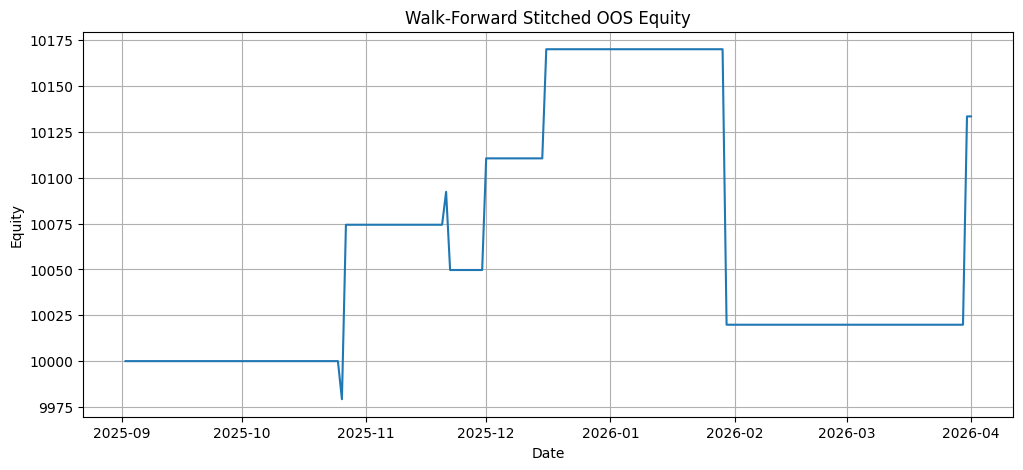

In [43]:
eq = wfa_result["stitched_oos_equity"]

if not eq.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(eq.index, eq["equity"])
    plt.title("Walk-Forward Stitched OOS Equity")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True)
    plt.show()

# просмотр OOS результатов по окнам

In [44]:
cols = [
    "window_id",
    "train_start", "train_end",
    "test_start", "test_end",
    "is_return_pct", "oos_return_pct",
    "is_pf", "oos_pf",
    "oos_n_trades"
]

wfa_result["windows_df"][cols]

,window_id,train_start,train_end,test_start,test_end,is_return_pct,oos_return_pct,is_pf,oos_pf,oos_n_trades
0,1,2025-05-02,2025-09-02,2025-09-02,2025-10-02,0.776032,0.000000,2.518739,0.0,0
1,2,2025-06-02,2025-10-02,2025-10-02,2025-11-02,0.790915,0.743887,0.000000,0.0,1
2,3,2025-07-02,2025-11-02,2025-11-02,2025-12-02,2.354350,0.359432,0.000000,0.0,1
3,4,2025-08-02,2025-12-02,2025-12-02,2026-01-02,1.917186,0.588804,6.234643,0.0,1
4,5,2025-09-02,2026-01-02,2026-01-02,2026-02-02,3.309076,-1.477595,14.278636,0.0,1
5,6,2025-10-02,2026-02-02,2026-02-02,2026-03-02,2.312163,0.000000,3.211246,0.0,0
6,7,2025-11-02,2026-03-02,2026-03-02,2026-04-02,5.857444,1.134060,19.843399,0.0,1


# Просмотр всех OOS сделок

In [26]:
wfa_result["all_oos_trades_df"].head(20)

,entry_time,exit_time,size,price_in,price_out,pnl_gross,pnl_net,barlen,window_id
0,2026-02-06 19:55:00,2026-02-06 21:30:00,0.0,70788.504870,70788.504870,-17.286222,-19.719836,19,1
1,2026-02-07 01:50:00,2026-02-07 03:25:00,0.0,70548.096798,70548.096798,8.022768,3.755299,19,1
2,2026-02-20 17:50:00,2026-02-21 08:55:00,0.0,67533.944088,67533.944088,43.880540,38.832901,181,2
3,2026-02-28 21:40:00,2026-03-01 12:45:00,0.0,66833.734074,66833.734074,-16.746823,-19.256909,181,2
4,2026-03-03 19:40:00,2026-03-04 03:35:00,0.0,68614.730202,68614.730202,-72.010701,-75.569134,95,2
5,2026-03-04 15:05:00,2026-03-04 19:25:00,0.0,71684.974128,71684.974128,135.588148,131.567108,52,2
